In [12]:
import numpy as np #it turns your images into large mathematical matrices
import pandas as pd
import os #This allows Python to talk to your computer's folders and without it your code cannot find your data
import shutil #this is for moving files on our hard drive
import random #this deals with random shuffling inorder for the model to not become used to particular order


In [13]:
from google.colab import drive #this is the first step in telling Colab to reach into my private Google Drive and access the folders stored there.

In [14]:
drive.mount('/content/drive') #When running this, Google Colab will ask you for authorization. Once you give permission, your entire Google Drive becomes a folder inside the Colab environment.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
#this is used from the upload of images and conversion of images into numpy array

In [15]:
#this deals with the organization and seperation of the data into testing, training and validation

from logging import root
root_file  = '/content/drive/MyDrive/IMAGES' #where the original image is
next_root = '/content/drive/MyDrive/IMAGES_SPLIT' #where the organized folder will be met
classes   = ['Ai_generated_dataset', 'real_dataset']#this tells us that we have 2 classes of images real and Ai
random.seed(42)

# Clear the previous split directory to prevent accumulation
shutil.rmtree(next_root, ignore_errors=True)

for i in classes:
  files = os.listdir(os.path.join(root_file, i))
  random.shuffle(files)
  n=len(files)

  train_set = files[:int(n*0.70)]
  val_set = files[int(n*0.70): int(n*0.85)]
  test_set = files[int(n*0.85):]


  for s_name, s_files in [('train', train_set), ('val', val_set), ('test', test_set)]:
    nextset = os.path.join(next_root, s_name, i)
    os.makedirs(nextset, exist_ok=True)
    for f in s_files:
      shutil.copy(os.path.join(root_file, i, f), os.path.join(nextset, f))



In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
base_dir = '/content/drive/MyDrive/IMAGES_SPLIT'

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255,horizontal_flip=True, rotation_range=10, zoom_range=0.1)
eval_datagen  = ImageDataGenerator(rescale=1./255)

In [16]:
# train set
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(300, 300),
    batch_size=32,
    class_mode='binary'
    )

Found 354 images belonging to 2 classes.


In [18]:
val_generator = eval_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=(300, 300),
    class_mode='binary'
)

Found 76 images belonging to 2 classes.


In [19]:
test_generator = eval_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(300,300),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 77 images belonging to 2 classes.



    Analyze Class Distribution Methods: To analyze class distribution:
    train_generator.classes (from ImageDataGenerator) and np.unique with return_counts=True to get counts for each class index.
    train_generator.class_indices to map class indices back to meaningful class names.
    collections.Counter can also be used on train_generator.classes.
    matplotlib.pyplot.bar or seaborn.countplot for visualization of class distribution.

    Visualize Sample Images Methods: To visualize sample images:
    tensorflow.keras.preprocessing.image.load_img or PIL.Image.open to load an image from a file path.
    tensorflow.keras.preprocessing.image.img_to_array to convert the image to a NumPy array.
    matplotlib.pyplot.imshow to display the image array.
    os.listdir and os.path.join to navigate through image directories and select random images.

    Examine Image Dimensions and Resolution Methods: To examine image dimensions and resolution:
    PIL.Image.open(filepath).size to get the width and height of an image.
    PIL.Image.open(filepath).mode to get the number of channels (e.g., 'RGB', 'L').
    cv2.imread(filepath).shape (if using OpenCV) to get (height, width, channels).
    Iterate through a sample of images and collect their dimensions into a list or DataFrame for analysis (e.g., min, max, average dimensions).

    Study Pixel Value Distribution Methods: To study pixel value distribution:
    Load images into NumPy arrays using load_img and img_to_array.
    numpy.mean(), numpy.std() for calculating mean and standard deviation of pixel values across an image or the entire dataset.
    matplotlib.pyplot.hist to plot histograms of pixel intensity values (for grayscale or individual channels of RGB images).
    For RGB images, you might analyze each channel separately (e.g., image_array[:, :, 0] for red channel).

    Identify Corrupted or Invalid Images Methods: To identify corrupted or invalid images:
    Use try-except blocks around image loading functions (PIL.Image.open or cv2.imread). Corrupted images will often raise exceptions like PIL.UnidentifiedImageError or IOError.
    Check the return value of image loading functions; cv2.imread returns None for invalid images.
    Check if the loaded image array has expected dimensions and is not empty or None.

  
    Final Task: Summarize the key functions and methods identified for performing EDA on image datasets, emphasizing their role in understanding data characteristics before model building.








In [20]:
train_generator.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

### EDA

In [21]:
# class distribution
unique_classes, class_counts = np.unique(train_generator.classes, return_counts=True)

In [22]:
print(unique_classes)
print(class_counts)

[0 1]
[175 179]


In [23]:
# Map class indices to class names
class_names_map = {v: k for k, v in train_generator.class_indices.items()}

In [24]:
# Create a DataFrame
df = pd.DataFrame({
    'Class Index': unique_classes,
    'Count': class_counts
})

In [25]:
df['Class Name'] = df['Class Index'].map(class_names_map)

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_4079/690401416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class Name', y='Count', data=df, palette='viridis')


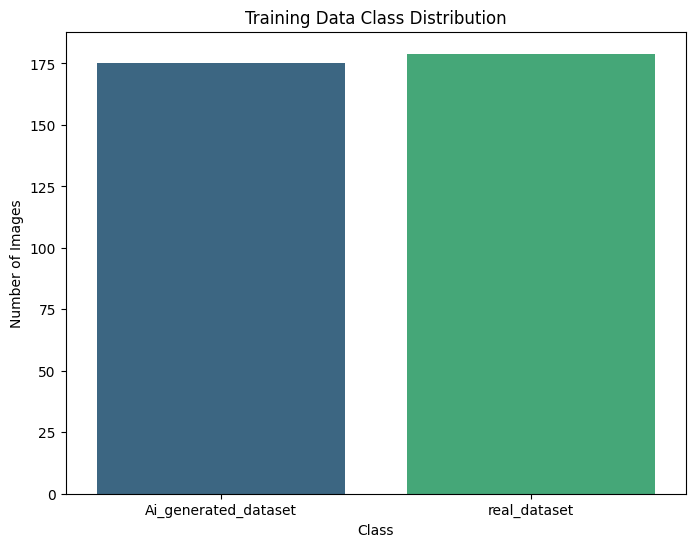

In [27]:
# Barplot class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x='Class Name', y='Count', data=df, palette='viridis')
plt.title('Training Data Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

### CNN Architecture


In [28]:
# import libraries
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential


In [29]:
classifier = Sequential([
    #
    Conv2D(16, (3, 3), activation='relu', input_shape=(300, 300, 3)),
    MaxPooling2D(2, 2),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    #
    #
    Flatten(),
    #hidden layer: this comprises of one layer
    Dense(256, activation='relu'),
    #
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 900,769 (3.44 MB)

 Trainable params: 900,769 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.optimizers import RMSprop

classifier.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision']
)

In [ ]:
classifier.fit(
    train_generator,
    epochs=10,
    validation_steps=0.2,
    verbose=1
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step - accuracy: 0.5282 - loss: 0.6820 - precision: 0.5337
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6102 - loss: 0.6691 - precision: 0.6133
Epoch 3/10
 1/12 ━━━━━━━━━━━━━━━━━━━━ 6:55 38s/step - accuracy: 0.7188 - loss: 0.5840 - precision: 0.8000

In [ ]:
classifier.evaluate(test_generator)

In [ ]:
classifier.evaluate(val_generator)

In [ ]:
img_path = '/content/drive/MyDrive/New samples/ai.jpeg'

img = load_img(img_path, target_size=(300, 300))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
image_tensor = np.vstack([x])
classes = classifier.predict(image_tensor, batch_size=10)

print(f"Classes: {classes}")
print(classes)

if classes[0] > 0.5:
    print(f"{img_path.split("/")[-1]}, it's a real image ")
else:
    print(f"{img_path.split("/")[-1]}, it's AI generated ")

In [ ]:
classifier.save("image_classifier.keras")